In [46]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm

sys.path.append("../src")
from MillerDataGen import (
    CompositionalDataGeneratorConfig,
    CompositionalDataGenerator,
)
from MillerTest import (
    CompositionalModelConfig,
    create_compositional_model,
)
from MillerTrainer import MillerTrainer, TrainerConfig

%matplotlib inline

In [ ]:
# Parameters and run flags
S1 = 8  # vocab size for slot 1 (e.g., color) was 24
S2 = 8  # vocab size for slot 2 (e.g., shape) was 24
SEQ_LEN = 3
BATCH_SIZE = 128
NUM_SAMPLES = 2000
FEATURE_DIM = 32
INIT_SCALE = 1.0
LR = 7e-3
N_EPOCHS = 300
SEED = 1

RUN_SINGLE_MODEL = True
RUN_MULTI_SEED = False
RUN_SLOT_SWEEP = False
RUN_CONFLICT_ANALYSIS = False
RUN_TRAJECTORY_SWEEP = False

device = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)

In [48]:
# Build per-feature (slot) distance matrices
# We'll use circular distances for both slots to mirror the clean notebook

def circular_distance_matrix(S: int) -> torch.Tensor:
    t = torch.linspace(0, 1 - 1/S, S).unsqueeze(1)
    D = torch.zeros((S, S))
    for i in range(S):
        for j in range(S):
            D[i, j] = torch.min(torch.abs(t[i] - t[j]), 1 - torch.abs(t[i] - t[j]))
    return D

D1 = circular_distance_matrix(S1)
D2 = circular_distance_matrix(S2)

In [49]:
# Instantiate generator and model
if RUN_SINGLE_MODEL:
    comp_conf = CompositionalDataGeneratorConfig(
        num_slots=2,
        vocab_sizes=(S1, S2),
        sequence_len=SEQ_LEN,
        batch_size=BATCH_SIZE,
        slot_metric_matrices=(D1, D2),
        seed=SEED,
        num_samples=NUM_SAMPLES,
    )
    # Ensure evaluator can read a device from the data generator config
    comp_conf.device = device

    comp_gen = CompositionalDataGenerator(comp_conf)

    comp_model_conf = CompositionalModelConfig(
        input_dim=S1 + S2,
        feature_dim=FEATURE_DIM,
        sequence_len=SEQ_LEN,
        vocab_sizes=(S1, S2),
        activation=torch.nn.ReLU(),
    )
    comp_model = create_compositional_model(comp_model_conf)

    # Initialize weights uniformly
    for layer in comp_model.slot_embedders:
        torch.nn.init.uniform_(layer.weight, a=0.0, b=INIT_SCALE)

    comp_model.to(device)

Epoch 0:
  Train - Sim Loss: 0.3271, Reconstruction Loss: 23.7282
  Val - G Score: 0.5300, I Score: 0.5833
Epoch 50:
  Train - Sim Loss: 0.3497, Reconstruction Loss: 0.0451
  Val - G Score: 0.7726, I Score: 0.8163
Epoch 100:
  Train - Sim Loss: 0.2061, Reconstruction Loss: 0.0324
  Val - G Score: 0.7827, I Score: 0.8189
Epoch 150:
  Train - Sim Loss: 0.1962, Reconstruction Loss: 0.0279
  Val - G Score: 0.7886, I Score: 0.8450
Epoch 200:
  Train - Sim Loss: 0.3408, Reconstruction Loss: 0.0674
  Val - G Score: 0.7663, I Score: 0.8127
Epoch 250:
  Train - Sim Loss: 0.2933, Reconstruction Loss: 0.0487
  Val - G Score: 0.7563, I Score: 0.8247


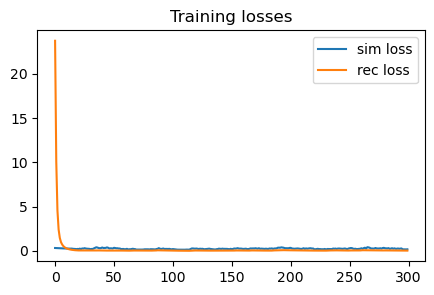

In [50]:
# Train
if RUN_SINGLE_MODEL:
    comp_tconf = TrainerConfig()
    comp_tconf.losses = ["reconstruction", "similarity"]
    comp_tconf.num_inputs = S1 + S2
    comp_tconf.batch_size = BATCH_SIZE
    comp_tconf.num_epochs = N_EPOCHS
    comp_tconf.learning_rate = LR
    comp_tconf.weight_decay = 0.0
    comp_tconf.patience = 700
    comp_tconf.min_lr = 0
    comp_tconf.lambda_rec = 0.5
    comp_tconf.lambda_sim = 0.5

    trainer = MillerTrainer(comp_model, comp_gen, comp_tconf)
    comp_history = trainer.train(printevery=50)

    plt.figure(figsize=(5,3))
    plt.plot(comp_history["similarity_losses"], label="sim loss")
    plt.plot(comp_history["reconstruction_losses"], label="rec loss")
    plt.legend(); plt.title("Training losses")

In [51]:
# Multi-seed training: identification vs generalization trajectories
# Mirrors the clean_experiment style: plot val similarity vs identification across epochs for multiple seeds

if RUN_MULTI_SEED:
    from MillerTest import MillerTestEvaluator, MillerTestConfig

    SEEDS = [1, 7, 13, 21, 37, 55]
    traj_hist = []

    for s in SEEDS:
        # fresh generator and model per seed
        comp_conf_s = CompositionalDataGeneratorConfig(
            num_slots=2,
            vocab_sizes=(S1, S2),
            sequence_len=SEQ_LEN,
            batch_size=BATCH_SIZE,
            slot_metric_matrices=(D1, D2),
            seed=s,
            num_samples=NUM_SAMPLES,
        )
        comp_conf_s.device = device
        comp_gen_s = CompositionalDataGenerator(comp_conf_s)

        comp_model_conf_s = CompositionalModelConfig(
            input_dim=S1 + S2,
            feature_dim=FEATURE_DIM,
            sequence_len=SEQ_LEN,
            vocab_sizes=(S1, S2),
            activation=torch.nn.ReLU(),
        )
        comp_model_s = create_compositional_model(comp_model_conf_s)
        for layer in comp_model_s.slot_embedders:
            torch.nn.init.uniform_(layer.weight, a=0.0, b=INIT_SCALE)
        comp_model_s.to(device)

        tconf_s = TrainerConfig()
        tconf_s.losses = ["reconstruction", "similarity"]
        tconf_s.num_inputs = S1 + S2
        tconf_s.batch_size = BATCH_SIZE
        tconf_s.num_epochs = 150
        tconf_s.learning_rate = LR
        tconf_s.weight_decay = 0.0
        tconf_s.patience = 700
        tconf_s.min_lr = 0
        tconf_s.lambda_rec = 0.5
        tconf_s.lambda_sim = 0.5

        trainer_s = MillerTrainer(comp_model_s, comp_gen_s, tconf_s)
        history = trainer_s.train(printevery=100)
        traj_hist.append((history['similarity_scores'], history['identification_scores']))

    # Plot trajectories like Figure 4
    plt.figure(figsize=(5,5))
    for g_scores, i_scores in traj_hist:
        plt.plot(g_scores, i_scores, linewidth=0.6, alpha=0.5)
    plt.xlim([0.48, 1.02])
    plt.ylim([0.48, 1.02])
    plt.xticks([0.5,0.6,0.7,0.8,0.9,1])
    plt.xlabel("Similarity (generalization)")
    plt.ylabel("Identification")
    plt.title("Compositional model: val trajectories")
    plt.show()


In [52]:
# Experiment with varying number of slots
if RUN_SLOT_SWEEP:
    def train_multi_slot_model(num_slots, vocab_size_per_slot=12, feature_dim=32, n_epochs=200, seed=42):
        """Train a compositional model with specified number of slots"""
        
        # Create distance matrices for each slot (using circular distance)
        slot_distances = []
        for i in range(num_slots):
            slot_distances.append(circular_distance_matrix(vocab_size_per_slot))
        
        # Create data generator
        slot_config = CompositionalDataGeneratorConfig(
            num_slots=num_slots,
            vocab_sizes=tuple([vocab_size_per_slot] * num_slots),
            sequence_len=SEQ_LEN,
            batch_size=BATCH_SIZE,
            slot_metric_matrices=tuple(slot_distances),
            seed=seed,
            num_samples=NUM_SAMPLES,
            distance_aggregation="max",
        )
        slot_config.device = device
        slot_gen = CompositionalDataGenerator(slot_config)
        
        # Create model
        total_input_dim = num_slots * vocab_size_per_slot
        slot_model_config = CompositionalModelConfig(
            input_dim=total_input_dim,
            feature_dim=feature_dim,
            sequence_len=SEQ_LEN,
            vocab_sizes=tuple([vocab_size_per_slot] * num_slots),
            activation=torch.nn.ReLU(),
        )
        slot_model = create_compositional_model(slot_model_config)
        
        # Initialize weights
        for layer in slot_model.slot_embedders:
            torch.nn.init.uniform_(layer.weight, a=0.0, b=INIT_SCALE)
        slot_model.to(device)
        
        # Training config
        train_config = TrainerConfig()
        train_config.losses = ["reconstruction", "similarity"]
        train_config.num_inputs = total_input_dim
        train_config.batch_size = BATCH_SIZE
        train_config.num_epochs = n_epochs
        train_config.learning_rate = LR * (2/num_slots)  # Scale LR with slots
        train_config.weight_decay = 0.0
        train_config.patience = 700
        train_config.min_lr = 0
        train_config.lambda_rec = 0.5
        train_config.lambda_sim = 0.5
        
        # Train
        trainer = MillerTrainer(slot_model, slot_gen, train_config)
        history = trainer.train(printevery=1000)  # Quiet training
        
        # Get final scores (already in history, but validated for sanity)
        final_val = trainer.validate()
        
        return {
            'model': slot_model,
            'generator': slot_gen,
            'history': history,
            'final_g_score': final_val['generalization_score'],
            'final_i_score': final_val['identification_score'],
            'num_slots': num_slots
        }

    # Train models with different numbers of slots
    slot_experiments = {}
    slot_counts = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

    print("Training models with varying number of slots...")
    for n_slots in slot_counts:
        print(f"\n--- Training with {n_slots} slots ---")
        slot_experiments[n_slots] = train_multi_slot_model(
            num_slots=n_slots,
            vocab_size_per_slot=12,  # Reduced to keep total dim manageable
            feature_dim=32,
            n_epochs=200,
            seed=42
        )
        print(f"Final scores - G: {slot_experiments[n_slots]['final_g_score']:.3f}, I: {slot_experiments[n_slots]['final_i_score']:.3f}")

In [53]:
# Visualize training dynamics across slot counts
if RUN_SLOT_SWEEP:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Final scores vs number of slots
    ax = axes[0]
    n_slots_list = sorted(slot_experiments.keys())
    g_scores = [slot_experiments[n]['final_g_score'] for n in n_slots_list]
    i_scores = [slot_experiments[n]['final_i_score'] for n in n_slots_list]

    ax.plot(n_slots_list, g_scores, 'o-', label='Generalization', markersize=8)
    ax.plot(n_slots_list, i_scores, 's-', label='Identification', markersize=8)
    ax.set_xlabel('Number of Slots')
    ax.set_ylabel('Score')
    ax.set_title('Performance vs Number of Slots')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(n_slots_list)

    # Plot 2: Training loss curves
    ax = axes[1]
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(n_slots_list)))
    for i, n in enumerate(n_slots_list):
        losses = slot_experiments[n]['history']['similarity_losses']
        ax.plot(losses, label=f'{n} slots', color=colors[i], alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Similarity Loss')
    ax.set_title('Training Dynamics')
    ax.legend()
    ax.set_xlim([0, 200])

    # Plot 3: Generalization vs Identification trajectory
    ax = axes[2]
    for idx, n in enumerate(n_slots_list):
        hist = slot_experiments[n]['history']
        g_traj = hist.get('similarity_scores', [slot_experiments[n]['final_g_score']])
        i_traj = hist.get('identification_scores', [slot_experiments[n]['final_i_score']])
        ax.plot(g_traj, i_traj, label=f'{n} slots', color=colors[idx], alpha=0.7)
        ax.scatter(g_traj[-1], i_traj[-1], s=50, color=colors[idx])

    ax.set_xlabel('Generalization Score')
    ax.set_ylabel('Identification Score')
    ax.set_title('G vs I Trajectory')
    ax.legend()
    ax.set_xlim([0.4, 1.0])
    ax.set_ylim([0.4, 1.0])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nSummary:")
    print("="*50)
    for n in n_slots_list:
        print(f"{n} slots: G={slot_experiments[n]['final_g_score']:.3f}, I={slot_experiments[n]['final_i_score']:.3f}")

In [54]:
# Analyze conflict resolution behavior with different numbers of slots
if RUN_CONFLICT_ANALYSIS:
    @torch.no_grad()
    def analyze_multi_slot_conflicts(model, generator, num_trials=2048):
        """
        For multi-slot models, create conflict scenarios where one candidate is closer
        in one slot, another is closer in a different slot, etc.
        """
        B = BATCH_SIZE
        num_slots = generator.config.num_slots
        vocab_size = generator.config.vocab_sizes[0]  # Assuming uniform vocab size
        
        # Track which slot "wins" in conflicts
        slot_wins = torch.zeros(num_slots)
        total_conflicts = 0
        
        # Also compare to different Lp norms
        lp_correct = {'L1': 0, 'L2': 0, 'Linf': 0, 'model': 0}
        
        for _ in range(num_trials // B):
            # Create probe
            probe = torch.randint(high=vocab_size, size=(B, num_slots))
            
            # Create candidates with controlled distances
            # For simplicity, make one candidate closer in slot 0, another in slot 1, etc.
            candidates = []
            for favored_slot in range(min(num_slots, SEQ_LEN-1)):  # We can only have SEQ_LEN-1 candidates
                cand = probe.clone()
                for s in range(num_slots):
                    if s == favored_slot:
                        # Make this slot very close
                        cand[:, s] = (probe[:, s] + 1) % vocab_size
                    else:
                        # Make other slots farther
                        cand[:, s] = (probe[:, s] + 5) % vocab_size
                candidates.append(cand)
            
            # Pad with random candidates if needed
            while len(candidates) < SEQ_LEN - 1:
                candidates.append(torch.randint(high=vocab_size, size=(B, num_slots)))
            
            # Construct input sequence
            inputs = torch.zeros((B, SEQ_LEN, num_slots), dtype=torch.long)
            for i, cand in enumerate(candidates):
                inputs[:, i, :] = cand
            inputs[:, -1, :] = probe
            
            # Get model predictions
            x = generator.indices_to_inputs(inputs).to(device)
            slot_embs = model.get_slot_embeddings(x)
            
            # Compute per-slot similarities
            per_slot_logits = []
            for s in range(num_slots):
                ctx = slot_embs[:, :-1, s, :]
                probe_emb = slot_embs[:, [-1], s, :]
                logits_s = torch.bmm(ctx, probe_emb.permute(0, 2, 1))
                per_slot_logits.append(logits_s.squeeze(-1))  # [B, K-1]
            
            # Stack to get [B, K-1, num_slots]
            per_slot_stack = torch.stack(per_slot_logits, dim=2)
            
            # Model uses max over slots
            model_logits = torch.max(per_slot_stack, dim=2).values
            model_choice = torch.argmax(model_logits, dim=1)
            
            # Track which slot was decisive (had the max similarity for chosen candidate)
            for b in range(B):
                chosen_idx = model_choice[b]
                if chosen_idx < num_slots:  # Only count if it's one of our controlled candidates
                    # Find which slot had max similarity for this choice
                    slot_sims = per_slot_stack[b, chosen_idx, :]
                    winning_slot = torch.argmax(slot_sims)
                    if winning_slot == chosen_idx:  # Slot matches the candidate designed for it
                        slot_wins[winning_slot] += 1
                        total_conflicts += 1
            
            # Compare with Lp norms
            # Compute distances for first min(num_slots, SEQ_LEN-1) candidates
            Ds = generator.config.slot_metric_matrices
            for norm_type in ['L1', 'L2', 'Linf']:
                distances = []
                for i in range(min(num_slots, SEQ_LEN-1)):
                    slot_dists = []
                    for s in range(num_slots):
                        d = Ds[s][candidates[i][:, s], probe[:, s]]
                        slot_dists.append(d)
                    slot_dists = torch.stack(slot_dists, dim=1)  # [B, num_slots]
                    
                    if norm_type == 'L1':
                        dist = torch.sum(slot_dists, dim=1)
                    elif norm_type == 'L2':
                        dist = torch.sqrt(torch.sum(slot_dists**2, dim=1))
                    else:  # Linf
                        dist = torch.max(slot_dists, dim=1).values
                    distances.append(dist)
                
                distances = torch.stack(distances, dim=1)  # [B, min(num_slots, K-1)]
                lp_choice = torch.argmin(distances, dim=1)
                
                # Count correct (choosing candidate 0 which is closest in slot 0, etc.)
                for b in range(B):
                    if lp_choice[b] < num_slots:
                        lp_correct[norm_type] += (lp_choice[b] == model_choice[b]).item()
            
            lp_correct['model'] += B
        
        # Normalize
        if total_conflicts > 0:
            slot_wins = slot_wins / total_conflicts
        
        for key in ['L1', 'L2', 'Linf']:
            if lp_correct['model'] > 0:
                lp_correct[key] = lp_correct[key] / lp_correct['model']
        
        return slot_wins.numpy(), lp_correct

    # Run conflict analysis for each model (requires slot sweep)
    if RUN_SLOT_SWEEP:
        print("\nConflict Resolution Analysis")
        print("="*50)

        conflict_results = {}
        for n_slots in slot_counts:
            print(f"\n{n_slots} slots:")
            model = slot_experiments[n_slots]['model']
            gen = slot_experiments[n_slots]['generator']
            
            slot_wins, lp_agreement = analyze_multi_slot_conflicts(model, gen)
            conflict_results[n_slots] = {'slot_wins': slot_wins, 'lp_agreement': lp_agreement}
            
            print(f"  Slot influence (% of conflicts won):")
            for i, win_rate in enumerate(slot_wins):
                print(f"    Slot {i}: {win_rate:.1%}")
            
            print(f"  Agreement with Lp norms:")
            for norm, agreement in lp_agreement.items():
                if norm != 'model':
                    print(f"    {norm}: {agreement:.1%}")

In [55]:

def train_with_trajectories(num_slots, vocab_size_per_slot=12, feature_dim=32, n_epochs=200, seed=42):
    """Train a compositional model while tracking validation scores at each epoch"""
    
    # Create distance matrices for each slot (using circular distance)
    slot_distances = []
    for i in range(num_slots):
        slot_distances.append(circular_distance_matrix(vocab_size_per_slot))
    
    # Create data generator
    slot_config = CompositionalDataGeneratorConfig(
        num_slots=num_slots,
        vocab_sizes=tuple([vocab_size_per_slot] * num_slots),
        sequence_len=SEQ_LEN,
        batch_size=BATCH_SIZE,
        slot_metric_matrices=tuple(slot_distances),
        seed=seed,
        num_samples=NUM_SAMPLES,
        distance_aggregation="max",
    )
    slot_config.device = device
    slot_gen = CompositionalDataGenerator(slot_config)
    
    # Create model
    total_input_dim = num_slots * vocab_size_per_slot
    slot_model_config = CompositionalModelConfig(
        input_dim=total_input_dim,
        feature_dim=feature_dim,
        sequence_len=SEQ_LEN,
        vocab_sizes=tuple([vocab_size_per_slot] * num_slots),
        activation=torch.nn.ReLU(),
    )
    slot_model = create_compositional_model(slot_model_config)
    
    # Initialize weights
    for layer in slot_model.slot_embedders:
        torch.nn.init.uniform_(layer.weight, a=0.0, b=INIT_SCALE)
    slot_model.to(device)
    
    # Training config
    train_config = TrainerConfig()
    train_config.losses = ["reconstruction", "similarity"]
    train_config.num_inputs = total_input_dim
    train_config.batch_size = BATCH_SIZE
    train_config.num_epochs = n_epochs
    train_config.learning_rate = LR * (2/num_slots) if num_slots > 1 else LR
    train_config.weight_decay = 0.0
    train_config.patience = 700
    train_config.min_lr = 0
    train_config.lambda_rec = 0.5
    train_config.lambda_sim = 0.5
    
    # Create trainer
    trainer = MillerTrainer(slot_model, slot_gen, train_config)
    
    # Train with trajectory tracking
    g_scores, i_scores, sim_losses = [], [], []
    
    for epoch in range(n_epochs):
        # Train one epoch
        trainer.train_epoch()
        
        # Get validation scores
        val_results = trainer.validate()
        g_scores.append(val_results['generalization_score'])
        i_scores.append(val_results['identification_score'])
        
        # Get training loss
        train_results = trainer.train_epoch()
        sim_losses.append(train_results['similarity_loss'])
        
        # Print progress occasionally
        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: G={val_results['generalization_score']:.3f}, I={val_results['identification_score']:.3f}")
    
    return {
        'model': slot_model,
        'generator': slot_gen,
        'g_trajectory': g_scores,
        'i_trajectory': i_scores,
        'loss_trajectory': sim_losses,
        'num_slots': num_slots
    }

# Train models with different slot counts and track trajectories
print("Training models with trajectory tracking...")
print("="*60)

slot_trajectory_experiments = {}
slot_counts_to_test = [1, 2, 3, 5, 7, 10, 15]  # Reduced set for clearer visualization

for n_slots in slot_counts_to_test:
    print(f"\nTraining with {n_slots} slots:")
    slot_trajectory_experiments[n_slots] = train_with_trajectories(
        num_slots=n_slots,
        vocab_size_per_slot=12,
        feature_dim=32,
        n_epochs=200,
        seed=42
    )
    final_g = slot_trajectory_experiments[n_slots]['g_trajectory'][-1]
    final_i = slot_trajectory_experiments[n_slots]['i_trajectory'][-1]
    print(f"  Final: G={final_g:.3f}, I={final_i:.3f}")


Training models with trajectory tracking...

Training with 1 slots:
  Epoch 0: G=0.527, I=0.604
  Epoch 50: G=0.711, I=0.903
  Epoch 100: G=0.724, I=0.904
  Epoch 150: G=0.734, I=0.896
  Final: G=0.768, I=0.881

Training with 2 slots:
  Epoch 0: G=0.509, I=0.583
  Epoch 50: G=0.562, I=0.741
  Epoch 100: G=0.573, I=0.753
  Epoch 150: G=0.597, I=0.747
  Final: G=0.605, I=0.786

Training with 3 slots:
  Epoch 0: G=0.506, I=0.576
  Epoch 50: G=0.558, I=0.711
  Epoch 100: G=0.531, I=0.677
  Epoch 150: G=0.539, I=0.697
  Final: G=0.545, I=0.697

Training with 5 slots:
  Epoch 0: G=0.501, I=0.564
  Epoch 50: G=0.526, I=0.674
  Epoch 100: G=0.540, I=0.639
  Epoch 150: G=0.533, I=0.627
  Final: G=0.524, I=0.614

Training with 7 slots:
  Epoch 0: G=0.501, I=0.561
  Epoch 50: G=0.522, I=0.686
  Epoch 100: G=0.515, I=0.614
  Epoch 150: G=0.519, I=0.600
  Final: G=0.520, I=0.598

Training with 10 slots:
  Epoch 0: G=0.501, I=0.557
  Epoch 50: G=0.510, I=0.647
  Epoch 100: G=0.507, I=0.613
  Epoch 1


Summary Statistics:

1 Slots:
  Final G: 0.7680
  Final I: 0.8814
  Max G reached: 0.8036 at epoch 10
  Max I reached: 0.9302 at epoch 19

2 Slots:
  Final G: 0.6050
  Final I: 0.7863
  Max G reached: 0.6391 at epoch 20
  Max I reached: 0.8112 at epoch 12

3 Slots:
  Final G: 0.5446
  Final I: 0.6966
  Max G reached: 0.5674 at epoch 29
  Max I reached: 0.7809 at epoch 18

5 Slots:
  Final G: 0.5241
  Final I: 0.6141
  Max G reached: 0.5461 at epoch 83
  Max I reached: 0.7286 at epoch 24

7 Slots:
  Final G: 0.5197
  Final I: 0.5975
  Max G reached: 0.5274 at epoch 68
  Max I reached: 0.6892 at epoch 39

10 Slots:
  Final G: 0.5090
  Final I: 0.5761
  Max G reached: 0.5204 at epoch 61
  Max I reached: 0.6493 at epoch 48

15 Slots:
  Final G: 0.5026
  Final I: 0.5608
  Max G reached: 0.5140 at epoch 100
  Max I reached: 0.6045 at epoch 51


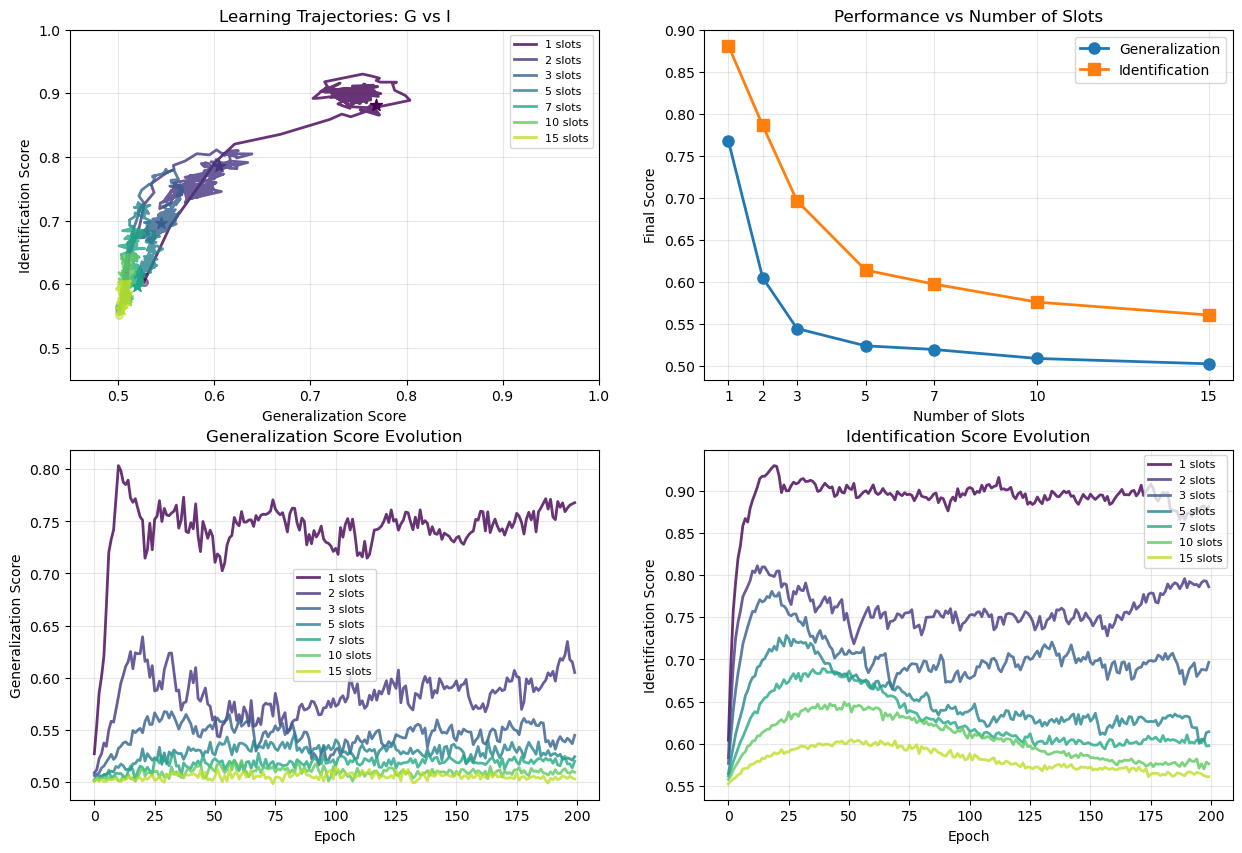

In [ ]:
# Visualize learning trajectories for different slot counts

fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor="")
axes = axes.flatten()

# Create color map
colors = cm.viridis(np.linspace(0, 0.9, len(slot_counts_to_test)))

# 1. G vs I trajectories (main plot)
ax = axes[0]
for idx, n_slots in enumerate(slot_counts_to_test):
    exp = slot_trajectory_experiments[n_slots]
    ax.plot(exp['g_trajectory'], exp['i_trajectory'], 
            label=f'{n_slots} slots', color=colors[idx], 
            linewidth=2, alpha=0.8)
    # Mark start and end
    ax.scatter(exp['g_trajectory'][0], exp['i_trajectory'][0], 
               color=colors[idx], s=30, marker='o', alpha=0.5)  # Start
    ax.scatter(exp['g_trajectory'][-1], exp['i_trajectory'][-1], 
               color=colors[idx], s=80, marker='*')  # End
ax.set_xlabel('Generalization Score')
ax.set_ylabel('Identification Score')
ax.set_title('Learning Trajectories: G vs I')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.45, 1.0])
ax.set_ylim([0.45, 1.0])

# 2. Final scores vs number of slots
ax = axes[1]
final_g = [slot_trajectory_experiments[n]['g_trajectory'][-1] for n in slot_counts_to_test]
final_i = [slot_trajectory_experiments[n]['i_trajectory'][-1] for n in slot_counts_to_test]
ax.plot(slot_counts_to_test, final_g, 'o-', label='Generalization', markersize=8, linewidth=2)
ax.plot(slot_counts_to_test, final_i, 's-', label='Identification', markersize=8, linewidth=2)
ax.set_xlabel('Number of Slots')
ax.set_ylabel('Final Score')
ax.set_title('Performance vs Number of Slots')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(slot_counts_to_test)

# 2. Generalization over epochs
ax = axes[2]
for idx, n_slots in enumerate(slot_counts_to_test):
    exp = slot_trajectory_experiments[n_slots]
    ax.plot(exp['g_trajectory'], label=f'{n_slots} slots', 
            color=colors[idx], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Generalization Score')
ax.set_title('Generalization Score Evolution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Identification over epochs
ax = axes[3]
for idx, n_slots in enumerate(slot_counts_to_test):
    exp = slot_trajectory_experiments[n_slots]
    ax.plot(exp['i_trajectory'], label=f'{n_slots} slots', 
            color=colors[idx], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Identification Score')
ax.set_title('Identification Score Evolution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# # 4. Loss curves
# ax = axes[3]
# for idx, n_slots in enumerate(slot_counts_to_test):
#     exp = slot_trajectory_experiments[n_slots]
#     ax.plot(exp['loss_trajectory'], label=f'{n_slots} slots', 
#             color=colors[idx], linewidth=2, alpha=0.8)
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Similarity Loss')
# ax.set_title('Training Loss Evolution')
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_yscale('log')

# # 6. Convergence speed (epochs to reach 90% of final score)
# ax = axes[5]
# convergence_epochs = []
# for n_slots in slot_counts_to_test:
#     exp = slot_trajectory_experiments[n_slots]
#     final_g = exp['g_trajectory'][-1]
#     target = 0.5 + 0.9 * (final_g - 0.5)  # 90% of the way from 0.5 to final
#     # Find first epoch where we exceed target
#     converged = next((i for i, g in enumerate(exp['g_trajectory']) if g >= target), len(exp['g_trajectory']))
#     convergence_epochs.append(converged)

# ax.bar(range(len(slot_counts_to_test)), convergence_epochs, 
#        color=colors, alpha=0.7, edgecolor='black')
# ax.set_xticks(range(len(slot_counts_to_test)))
# ax.set_xticklabels([str(n) for n in slot_counts_to_test])
# ax.set_xlabel('Number of Slots')
# ax.set_ylabel('Epochs to 90% Convergence')
# ax.set_title('Convergence Speed')
# ax.grid(True, alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
for n_slots in slot_counts_to_test:
    exp = slot_trajectory_experiments[n_slots]
    print(f"\n{n_slots} Slots:")
    print(f"  Final G: {exp['g_trajectory'][-1]:.4f}")
    print(f"  Final I: {exp['i_trajectory'][-1]:.4f}")
    print(f"  Max G reached: {max(exp['g_trajectory']):.4f} at epoch {np.argmax(exp['g_trajectory'])}")
    print(f"  Max I reached: {max(exp['i_trajectory']):.4f} at epoch {np.argmax(exp['i_trajectory'])}")